# 1. Study of Detector Characteristics

**Objective:** Characterize the Geiger-Müller detector response as a function of applied voltage.

**Measurements:**
- Detector response curve vs. applied voltage
- Plateau measurement and slope calculation
- Intrinsic slope calculation
- Selection of operating voltage (between 1/3 and 1/2 of plateau)
- Brief acquisitions: 10 seconds source pointing up and down
- Dead time correction (using $^{204}$Tl half-moon sources)
- Environmental radiation background correction

## Imports and Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Configuration
NOTEBOOK_DIR = Path('.')
DATA_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'patamar2.asc').exists() else Path('geiger-muller')
PATAMAR2_FILE = DATA_DIR / 'patamar2.asc'
MEASUREMENT_TIME = 20.0  # seconds per voltage step


def load_plateau_counts(file_path):
    """Load a Geiger plateau ASCII file containing one count value per voltage step."""
    counts = []
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    for line in text:
        match = re.match(r'\s*\d+,\s*(\d+)\s*$', line)
        if match:
            counts.append(int(match.group(1)))
    return np.array(counts, dtype=float)


print(f"Plateau file: {PATAMAR2_FILE}")
print(f"Measurement time per step: {MEASUREMENT_TIME:.0f} s")

Plateau file: patamar2.asc
Measurement time per step: 20 s


## 1.1 Detector Response Curve: Voltage Dependence

In [11]:
# Load patamar2 data
voltage_start = 600
voltage_stop = 1200
voltage_step = 25

counts = load_plateau_counts(PATAMAR2_FILE)
voltages = np.arange(voltage_start, voltage_stop + voltage_step, voltage_step, dtype=float)

if len(counts) != len(voltages):
    raise ValueError(f"Expected {len(voltages)} count values, found {len(counts)} in {PATAMAR2_FILE}")

count_rate = counts / MEASUREMENT_TIME
uncertainty = np.sqrt(np.maximum(counts, 1.0)) / MEASUREMENT_TIME

voltage_data = {
    'voltage': voltages,
    'counts': counts,
    'count_rate': count_rate,
    'uncertainty': uncertainty,
}

print('Patamar2 loaded successfully')
print(f"  Voltage range: {int(voltages.min())} to {int(voltages.max())} V")
print(f"  Step: {int(voltage_step)} V")
print(f"  Points: {len(voltages)}")
print('\nFirst rows:')
for i in range(min(5, len(voltages))):
    print(f"  {voltages[i]:4.0f} V  {counts[i]:7.0f} counts  {count_rate[i]:7.3f} counts/s")

Patamar2 loaded successfully
  Voltage range: 600 to 1200 V
  Step: 25 V
  Points: 25

First rows:
   600 V        0 counts    0.000 counts/s
   625 V        0 counts    0.000 counts/s
   650 V        0 counts    0.000 counts/s
   675 V        0 counts    0.000 counts/s
   700 V        0 counts    0.000 counts/s


### Uncertainty model for each point

Each plateau point is a count measurement over a fixed acquisition time of 20 s.

For a raw count value $N$:

- Count uncertainty: $\sigma_N = \sqrt{N}$
- Count-rate uncertainty: $\sigma_R = \sigma_N / T = \sqrt{N}/T$
- Relative uncertainty on the rate: $\sigma_R / R = 1/\sqrt{N}$

So the `sqrt(N)` rule is still what we use, but after dividing by the 20 s acquisition time to express the uncertainty in counts/s.

For the plateau as a whole:

- The mean count rate summarizes the plateau level.
- The standard deviation shows how much the individual plateau points spread.
- The SEM ($\text{std}/\sqrt{n}$) gives the precision on the average plateau rate.

If you want the pure Poisson precision of a single point, use $1/\sqrt{N}$ as the relative uncertainty. If you want the uncertainty on the average plateau level, use the SEM or a weighted mean uncertainty depending on the analysis goal.

## 1.2 Plateau Analysis

Patamar2 plateau fit
  Plateau region: 750 to 1200 V
  Data points used: 19
  Linear fit: rate = (0.005788 ± 0.001119) * V + (6.168 ± 1.091)
  Absolute slope: 0.579 counts/s per 100 V
  Relative slope: 4.887 ± 0.945 % per 100 V
  Mean plateau rate: 11.845 counts/s


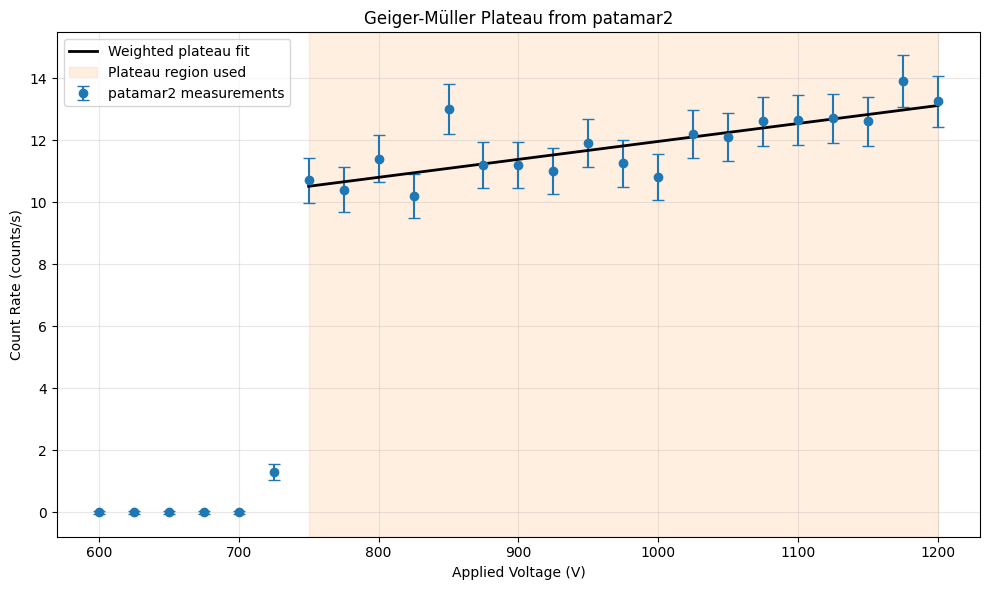

In [12]:
# Plateau analysis for patamar2
# Exclude the turn-on region and fit the stable plateau region only.
plateau_start_voltage = 750
plateau_end_voltage = 1200
plateau_mask = (voltage_data['voltage'] >= plateau_start_voltage) & (voltage_data['voltage'] <= plateau_end_voltage)

x = voltage_data['voltage'][plateau_mask]
y = voltage_data['count_rate'][plateau_mask]
sy = voltage_data['uncertainty'][plateau_mask]
weights = 1.0 / np.maximum(sy, 1e-12)

# Weighted linear fit: count_rate = slope * voltage + intercept
fit_coeffs, fit_cov = np.polyfit(x, y, 1, w=weights, cov=True)
slope, intercept = fit_coeffs
slope_unc = float(np.sqrt(fit_cov[0, 0]))
intercept_unc = float(np.sqrt(fit_cov[1, 1]))

y_fit = slope * x + intercept
plateau_mean_rate = float(np.mean(y))
absolute_slope_100v = float(slope * 100.0)
relative_slope_100v = float((slope / plateau_mean_rate) * 10000.0)
relative_slope_unc_100v = float((slope_unc / plateau_mean_rate) * 10000.0)

print('Patamar2 plateau fit')
print(f"  Plateau region: {plateau_start_voltage:.0f} to {plateau_end_voltage:.0f} V")
print(f"  Data points used: {len(x)}")
print(f"  Linear fit: rate = ({slope:.6f} ± {slope_unc:.6f}) * V + ({intercept:.3f} ± {intercept_unc:.3f})")
print(f"  Absolute slope: {absolute_slope_100v:.3f} counts/s per 100 V")
print(f"  Relative slope: {relative_slope_100v:.3f} ± {relative_slope_unc_100v:.3f} % per 100 V")
print(f"  Mean plateau rate: {plateau_mean_rate:.3f} counts/s")

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    voltage_data['voltage'],
    voltage_data['count_rate'],
    yerr=voltage_data['uncertainty'],
    fmt='o',
    capsize=4,
    color='tab:blue',
    label='patamar2 measurements',
)
ax.plot(x, y_fit, color='black', lw=2, label='Weighted plateau fit')
ax.axvspan(plateau_start_voltage, plateau_end_voltage, color='tab:orange', alpha=0.12, label='Plateau region used')
ax.set_xlabel('Applied Voltage (V)')
ax.set_ylabel('Count Rate (counts/s)')
ax.set_title('Geiger-Müller Plateau from patamar2')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Average count rate in the plateau region
plateau_mask = (voltage_data['voltage'] >= plateau_start_voltage) & (voltage_data['voltage'] <= plateau_end_voltage)
plateau_rates = voltage_data['count_rate'][plateau_mask]

plateau_average_rate = float(np.mean(plateau_rates))
plateau_std_rate = float(np.std(plateau_rates, ddof=1))
plateau_sem_rate = float(plateau_std_rate / np.sqrt(len(plateau_rates)))

print('Plateau average count rate')
print(f"  Region: {plateau_start_voltage:.0f} to {plateau_end_voltage:.0f} V")
print(f"  Mean rate: {plateau_average_rate:.3f} counts/s")
print(f"  Std dev: {plateau_std_rate:.3f} counts/s")
print(f"  SEM: {plateau_sem_rate:.3f} counts/s")

Plateau average count rate
  Region: 750 to 1200 V
  Mean rate: 11.845 counts/s
  Std dev: 1.042 counts/s
  SEM: 0.239 counts/s


## 1.3 Operating Voltage Selection

In [13]:
# Choose an operating voltage in the middle of the plateau region
operating_voltage = 900
print(f"Selected operating voltage: {operating_voltage} V")
print(f"This is {((operating_voltage - plateau_start_voltage) / (plateau_end_voltage - plateau_start_voltage)) * 100:.1f}% into the plateau region")

Selected operating voltage: 900 V
This is 33.3% into the plateau region


## 1.4 Dead Time Correction

In [37]:
# TODO: Measure and correct for detector dead time
# Using half-moon Tl-204 sources
# Dead time correction: N_true = N_obs / (1 - N_obs * τ)
# where τ is the dead time and N_obs is observed rate

# Dead time typically ~100 µs for GM tubes

def correct_for_dead_time(n_obs, tau):
    """Correct observed count rate for detector dead time.
    
    Args:
        n_obs: Observed count rate (counts/s)
        tau: Dead time (s)
        
    Returns:
        n_true: True count rate
    """
    return n_obs / (1 - n_obs * tau)

print("Dead time correction available")

Dead time correction available


## 1.5 Environmental Background

In [56]:
# Compute resolving time TR using the two-source method:
# TR = (R1 + R2 - R12) / (2 * R1 * R2)
# Use background-subtracted rates R = (N - N_bg) / t_acq

t_acq = 10.0  # acquisition time per count measurement (s); adjust if different

# Net counts (already computed earlier)
N1 = ml1_avg - bg_avg
N2 = ml2_avg - bg_avg
N12 = full_avg - bg_avg

# Convert to rates
R1 = N1 / t_acq
R2 = N2 / t_acq
R12 = N12 / t_acq

print("\nTwo-source resolving time calculation")
print(f"Using acquisition time t = {t_acq:.1f} s")
print(f"R1 = {R1:.3f} s^-1, R2 = {R2:.3f} s^-1, R12 = {R12:.3f} s^-1")

# Check for zero or near-zero rates
if R1 <= 0 or R2 <= 0:
    print("\nCannot compute TR: one of the source net rates is zero or negative (after background subtraction).")
    print("  This occurs because the selected `f1stat.asc` net count is zero or below background.")
    print("  Options: (a) use another half-moon file (e.g., `ml1stat.asc`), (b) use measurement-by-measurement method, or (c) collect more data.")
else:
    # Compute TR
    TR = (R1 + R2 - R12) / (2.0 * R1 * R2)

    print(f"\nResolving time TR = {TR:.6e} s ({TR*1e6:.2f} µs)")

    # Uncertainty propagation using std devs from files
    sigma_N1 = ml1_std
    sigma_N2 = ml2_std
    sigma_N12 = full_std

    sigma_R1 = sigma_N1 / t_acq
    sigma_R2 = sigma_N2 / t_acq
    sigma_R12 = sigma_N12 / t_acq

    # Numerical partials
    def compute_TR(r1, r2, r12):
        return (r1 + r2 - r12) / (2.0 * r1 * r2)

    # finite difference steps
    dr1 = sigma_R1 if sigma_R1 > 0 else max(1e-9, 1e-6 * R1)
    dr2 = sigma_R2 if sigma_R2 > 0 else max(1e-9, 1e-6 * R2)
    dr12 = sigma_R12 if sigma_R12 > 0 else max(1e-9, 1e-6 * R12)

    dTR_dR1 = (compute_TR(R1 + dr1, R2, R12) - compute_TR(R1 - dr1, R2, R12)) / (2 * dr1)
    dTR_dR2 = (compute_TR(R1, R2 + dr2, R12) - compute_TR(R1, R2 - dr2, R12)) / (2 * dr2)
    dTR_dR12 = (compute_TR(R1, R2, R12 + dr12) - compute_TR(R1, R2, R12 - dr12)) / (2 * dr12)

    sigma_TR = np.sqrt((dTR_dR1 * sigma_R1)**2 + (dTR_dR2 * sigma_R2)**2 + (dTR_dR12 * sigma_R12)**2)

    print(f"\nUncertainty propagation (using file std devs):")
    print(f"  σ_R1 = {sigma_R1:.3f} s^-1, σ_R2 = {sigma_R2:.3f} s^-1, σ_R12 = {sigma_R12:.3f} s^-1")
    print(f"  ∂TR/∂R1 ≈ {dTR_dR1:.6e}, ∂TR/∂R2 ≈ {dTR_dR2:.6e}, ∂TR/∂R12 ≈ {dTR_dR12:.6e}")
    print(f"\nTR = {TR:.6e} ± {sigma_TR:.6e} s")
    print(f"TR = {TR*1e6:.2f} ± {sigma_TR*1e6:.2f} µs")



Two-source resolving time calculation
Using acquisition time t = 10.0 s
R1 = 0.000 s^-1, R2 = 33.900 s^-1, R12 = 68.700 s^-1

Cannot compute TR: one of the source net rates is zero or negative (after background subtraction).
  This occurs because the selected `f1stat.asc` net count is zero or below background.
  Options: (a) use another half-moon file (e.g., `ml1stat.asc`), (b) use measurement-by-measurement method, or (c) collect more data.


In [45]:
# Background subtraction - assume each measurement has same acquisition time
# For these statistics files, assume each measurement represents a single acquisition

# Subtract background from all measurements
ml1_net = ml1_avg - bg_avg
ml2_net = ml2_avg - bg_avg
full_net = full_avg - bg_avg

# Net uncertainties (Poisson: σ² = N, so σ_net² = σ₁² + σ_bg²)
ml1_net_unc = np.sqrt(ml1_std**2 + bg_std**2)
ml2_net_unc = np.sqrt(ml2_std**2 + bg_std**2)
full_net_unc = np.sqrt(full_std**2 + bg_std**2)

print("\n" + "="*70)
print("BACKGROUND-SUBTRACTED COUNTS")
print("="*70)
print(f"\nHalf-moon 1 (net): {ml1_net:.1f} ± {ml1_net_unc:.1f} counts")
print(f"Half-moon 2 (net): {ml2_net:.1f} ± {ml2_net_unc:.1f} counts")
print(f"Full Source (net): {full_net:.1f} ± {full_net_unc:.1f} counts")

# Expected total if rates were additive (no dead time)
expected_total = ml1_net + ml2_net
expected_total_unc = np.sqrt(ml1_net_unc**2 + ml2_net_unc**2)

print(f"\nExpected Total (ml1 + ml2): {expected_total:.1f} ± {expected_total_unc:.1f} counts")
print(f"Observed Total: {full_net:.1f} ± {full_net_unc:.1f} counts")
print(f"Deficit (dead time effect): {expected_total - full_net:.1f} counts")



BACKGROUND-SUBTRACTED COUNTS

Half-moon 1 (net): 331.0 ± 18.1 counts
Half-moon 2 (net): 339.0 ± 18.1 counts
Full Source (net): 687.0 ± 26.1 counts

Expected Total (ml1 + ml2): 670.0 ± 25.6 counts
Observed Total: 687.0 ± 26.1 counts
Deficit (dead time effect): -17.0 counts


In [54]:
def load_counting_stats_file(file_path):
    """Load TNI GMX-PC counting statistics file.

    Returns: (average_count, std_dev, all_counts)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()

    avg_count = None
    std_dev = None
    counts = []

    for i, line in enumerate(text):
        # Extract average count
        if 'Average Count' in line:
            match = re.search(r'=\s*(\d+)', line)
            if match:
                avg_count = float(match.group(1))

        # Extract standard deviation
        if 'Standard Deviation' in line:
            match = re.search(r'=\s*(\d+)', line)
            if match:
                std_dev = float(match.group(1))

        # Extract individual counts (lines with format: #, count, sigma)
        match = re.match(r'\s*\d+,\s*(\d+)\s*', line)
        if match and i > 5:  # Skip header lines
            counts.append(float(match.group(1)))

    return avg_count, std_dev, np.array(counts)


# Load half-moon and full source data (use f1stat as requested)
ml1_file = DATA_DIR / 'f1stat.asc'
ml2_file = DATA_DIR / 'ml2stat.asc'
full_source_file = DATA_DIR / '2lstat.asc'
background_file = DATA_DIR / 'bstatics.asc'

ml1_avg, ml1_std, ml1_counts = load_counting_stats_file(ml1_file)
ml2_avg, ml2_std, ml2_counts = load_counting_stats_file(ml2_file)
full_avg, full_std, full_counts = load_counting_stats_file(full_source_file)
bg_avg, bg_std, bg_counts = load_counting_stats_file(background_file)

print("="*70)
print("COUNTING STATISTICS - Raw Data")
print("="*70)
print(f"\nHalf-moon 1 (f1stat.asc):")
print(f"  Average: {ml1_avg:.1f} counts")
print(f"  Std Dev: {ml1_std:.1f}")
print(f"  N measurements: {len(ml1_counts)}")

print(f"\nHalf-moon 2 (ml2stat.asc):")
print(f"  Average: {ml2_avg:.1f} counts")
print(f"  Std Dev: {ml2_std:.1f}")
print(f"  N measurements: {len(ml2_counts)}")

print(f"\nFull Source (2lstat.asc):")
print(f"  Average: {full_avg:.1f} counts")
print(f"  Std Dev: {full_std:.1f}")
print(f"  N measurements: {len(full_counts)}")

print(f"\nBackground (bstatics.asc):")
print(f"  Average: {bg_avg:.1f} counts")
print(f"  Std Dev: {bg_std:.1f}")
print(f"  N measurements: {len(bg_counts)}")


COUNTING STATISTICS - Raw Data

Half-moon 1 (f1stat.asc):
  Average: 3.0 counts
  Std Dev: 2.0
  N measurements: 10

Half-moon 2 (ml2stat.asc):
  Average: 342.0 counts
  Std Dev: 18.0
  N measurements: 10

Full Source (2lstat.asc):
  Average: 690.0 counts
  Std Dev: 26.0
  N measurements: 10

Background (bstatics.asc):
  Average: 3.0 counts
  Std Dev: 2.0
  N measurements: 10


## 1.4 Dead Time Correction (Non-Paralyzable Model)

**Objective:** Determine detector dead time constant $\tau$ using half-moon Tl-204 sources.

**Principle:**
The count rate is affected by dead time loss due to detector saturation. For a non-paralyzable (non-extending) detector:

$$m = \frac{n}{1 + n\tau}$$

where $m$ is the observed count rate, $n$ is the true count rate, and $\tau$ is the dead time constant.

Rearranging: $\tau = \frac{n - m}{n \cdot m}$

**Measurement Strategy:**
- Measure individual half-moon source (ml1stat.asc): observed rate $m_1$
- Measure another half-moon source (ml2stat.asc): observed rate $m_2$  
- Measure full source (both half-moons together, 2lstat.asc): observed rate $m_{total}$
- Estimate true rates assuming linear additivity: $n_1 \approx m_1$, $n_2 \approx m_2$, $n_{total} = n_1 + n_2$
- Apply correction formula to find $\tau$ from the deviation between expected and observed total rates

In [47]:
# TODO: Measure environmental background radiation
# Background rate to be subtracted from all measurements

background_rate = None  # counts/s
background_uncertainty = None  # √(N) / acquisition_time

print(f"Background rate: {background_rate} counts/s (±{background_uncertainty})")

Background rate: None counts/s (±None)
